For performing new tracing first import and make Tracer object based on config file settings.
The config file contains locations of images and ROIs for tracing, as well as settings for tracing, quality control and data output and saving.

If the analysis has already been run before, we can load the data instead:

In [1]:
import pandas as pd
import numpy as np
import os
import chromatin_tracing_python.image_processing_functions as ip
import chromatin_tracing_python.tracing_functions as tr
from chromatin_tracing_python.tracer_h5 import Tracer_decon

T=Tracer_decon(r"M:\ChromatinTeam\Images_processing\20200603_Exp328_KSB_Elyra_tracing_myc_D1-10\20200604_Exp_328_tracing_config_decon_h5.yaml")
wdir = r"M:\ChromatinTeam\Images_processing\20200603_Exp328_KSB_Elyra_tracing_myc_D1-10\04_TRACING"+os.sep
traces = pd.read_hdf(wdir+"20200603_Exp328_KSB_Elyra_tracing_myc_D1-10_v1_decon__traces.h5")
imgs=np.moveaxis(ip.read_tif_image(wdir+'20200603_Exp328_KSB_Elyra_tracing_myc_D1-10_v1_decon__imgs.tiff'),1,2)

traces=T.reapply_QC(traces)

Once we have the traces loaded or calculated, we can look at the trace dataframe. It has a multilevel index with a unique trace ID as main index, and image name, nuclear ownership and frame nr as secondary index for each point. Each fitted point is documented with the full output of the gaussian fit, as well as a quality control metric defined from the config file. Units in nm.

In [ ]:
traces.head()
traces.query('trace_ID == 40')

We can easily visualize one or more traces by their trace_IDs now, either one or several (by a list of trace_IDs). To do this we load the tracing functions module that contains several helper functions for trace analysis.

In [ ]:
tr.plot_traces(traces,[40])

Let us get some more statistics on our traces:

In [ ]:
import plotly.express as px
px.histogram(traces.groupby(level='trace_ID').sum(), x='QC', histnorm='percent', width=500)

In [ ]:
px.bar(traces.groupby('frame').sum(), y='QC', width=500)

Visualize fits on top of actual image data using napari.

In [ ]:
import napari
points=tr.points_for_overlay(traces)
with napari.gui_qt():
    viewer = napari.view_image(np.moveaxis(np.max(imgs,axis=2),0,1), contrast_limits=(100,10000))
    viewer.add_points(points[:,(0,1,3,4)], size=[0,0,1,1], face_color='blue', symbol='cross', n_dimensional=True)

In [ ]:
imgs.shape

Depending on the quality of the dataset, some traces might be too short for a useful anaylsis. These can be filtered out from the traces and pair-wise distance matrix before analysing further. Once filtered, we can get a sense of the data from the average pwd matrix (missing distances are nan, so we have to use nanmean).

In [2]:
traces_long = tr.tracing_length_qc(traces, min_length=9)
pwds_long = tr.pwd_calc(traces_long)

In [ ]:
print('Number of traces in analysis: ', pwds_long.shape[0])
pwds_mean=np.clip(np.round(-np.nanmedian(pwds_long, axis=0),0).astype(int),-600,0)

import plotly.figure_factory as ff
fig = ff.create_annotated_heatmap(pwds_mean,colorscale='hot')
fig.update_layout(
    width = 600,
    height = 600,
    yaxis_autorange="reversed"
)
fig.show()

Further, we can do a paired analysis on traces to figure out similarities between sets of traces. The output of this analysis contains the original indexes and point coordinates of the two compared indexes, the second trace aligned to the first by least squares fitting, and three metrics of similarity between the two traces. These are the mse of the alignment, and the mse of the two pair-wise distance matrices, as well as the Pearson's correlation coefficient between the PWDs. We sort the matrix for to find pairs with a high PCC.

In [3]:
pairs = tr.trace_analysis(traces_long, pwds_long)
pairs.sort_values(by=['pwd_pcc'], ascending=False).head()

,idx1,idx2,A,A_idx,B,B_idx,B_aligned,B_aligned_idx,aligned_mse,pwd_mse,pwd_pcc
1456,37,40,"[[2497.995355284677, 1954.898967068501, 1076.8...",trace_ID 37 1 37 2 37 3 37 4 3...,"[[1721.9571905978098, 1954.9147401822238, 1676...",trace_ID 40 1 40 2 40 3 40 4 4...,"[[2499.3031550773276, 1955.087755986236, 1076....",trace_ID 40 1 40 2 40 3 40 4 4...,7.955973,21.355496,0.999971
1403,34,56,"[[1521.5196869227993, 1678.5013331186442, 1885...",trace_ID 34 1 34 2 34 3 34 4 34 ...,"[[1773.0930921937331, 1762.141371115693, 1242....",trace_ID 56 1 56 2 56 3 56 4 56 ...,"[[1574.5277307587676, 1688.0342710387677, 1845...",trace_ID 56 1 56 2 56 3 56 4 56 ...,1644.055813,3431.989902,0.927486
1911,59,60,"[[1904.5921967206493, 1836.263100157462, 1283....",trace_ID 59 1 59 2 59 3 59 4 5...,"[[2085.8049572607238, 1377.673888377324, 1752....",trace_ID 60 1 60 2 60 3 60 4 6...,"[[1840.5569134604664, 1776.7309006890894, 1146...",trace_ID 60 1 60 2 60 3 60 4 6...,4737.099821,12026.728135,0.923634
263,6,27,"[[1836.4860915341608, 1805.3970309385581, 1620...",trace_ID 6 1 6 2 6 3 6 4 6 ...,"[[1779.0059827093553, 1698.8785400568547, 1429...",trace_ID 27 1 27 2 27 3 27 4 2...,"[[1825.903514148809, 1859.6207739138536, 1605....",trace_ID 27 1 27 2 27 3 27 4 2...,1022.667228,2550.840876,0.923255
918,20,57,"[[1810.1561782649267, 1858.9969990667719, 1628...",trace_ID 20 1 20 2 20 3 20 4 20 ...,"[[1800.0582618280878, 1897.891533450239, 1445....",trace_ID 57 1 57 2 57 3 57 4 57 ...,"[[1788.0096441399496, 1816.857762303965, 1592....",trace_ID 57 1 57 2 57 3 57 4 57 ...,2419.357515,6847.811036,0.914585


We can visualize the aligned traces by their index in the pair matrix.

In [49]:
tr.plot_paired_traces(pairs, pairs[(pairs['idx1']==34) & (pairs['idx2']==53)].index[0])

We can immediately use the paired similarity values to group the traces. We can use any of the three similarity metrics defined in the pairs analysis. This constructs a dendrogram showing simple hierichal grouping of the dataset. The labels in the dendrogram are the original trace_id of each trace.

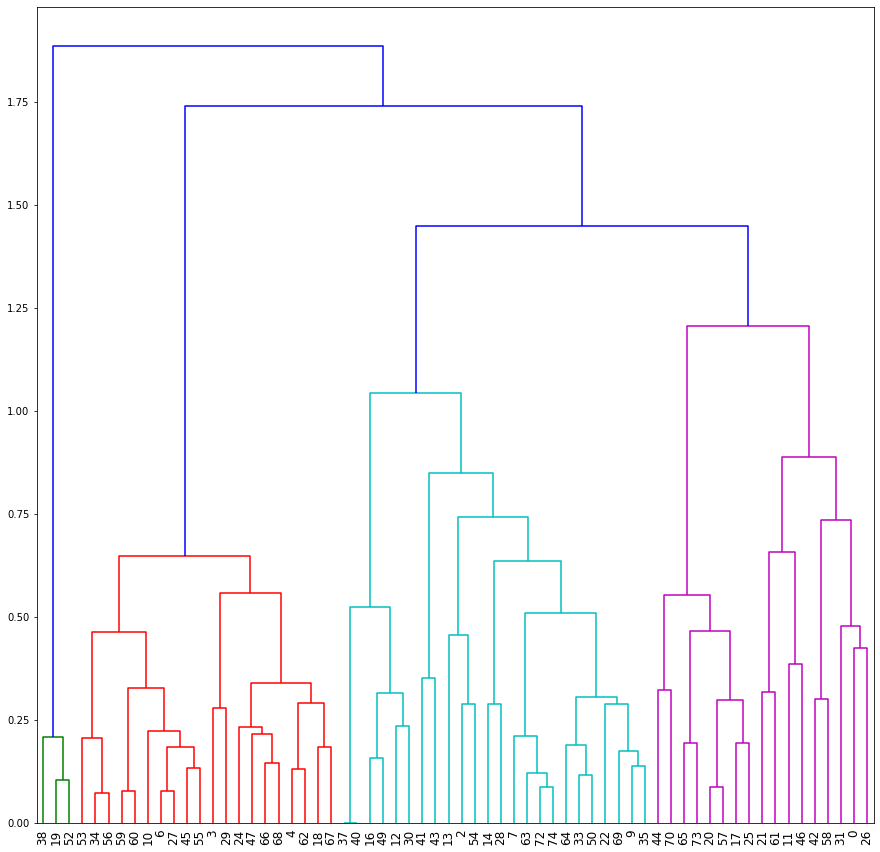

In [46]:
Z = tr.trace_clustering(pairs, metric='pwd_pcc', method='ward')

In [5]:
## Load R

## Before starting
# install R (tested on R 4.0.0)
# in cmd
# pip install rpy2
# add "C:\Program Files\R\R-4.0.0\bin\x64" to environment variables
import os
os.environ['R_HOME'] = r'C:\Program Files\R\R-4.0.0'
%load_ext rpy2.ipython

# print(pairs.head)
# print(traces.head)
pairs_df = pairs.astype(str)
traces_df = traces.copy()

ModuleNotFoundError: No module named 'rpy2'

In [ ]:
%%R
# import df from global environment
# make default figure size 5 by 5 inches with 200 dpi resolution
library("abind")
library("tidyr")
library("geomorph")

# Define functions in R

# Run Generalized Procrustes analysis
geomorph_gpa = function(traces_df, group_IDs_i){
    
    # Clean up the traces_df after import to R
    df = gsub("[(]", "", rownames(traces_df))
    df = gsub("[)]", "", df)
    df = strsplit(x = df, split = ",")
    df = do.call(rbind, lapply(df, function(x){
        data.frame(trace_ID = x[1], img_name = x[2], roi_ID = x[3], cell_ID = x[4], frame = x[5])
    }))
    traces_df = cbind(df, traces_df)
    rownames(traces_df) = NULL
    remove(df)
    
    # Analysis of traces_df
    # find traces belonging to each group
    bool = sapply(traces_df$trace_ID, function(id){
    any(id == group_IDs_i)
    })
    out = subset(traces_df, bool)
  
    # remove QC points 
    out = subset(out, QC == 1)
  
    # Add NA if missing data
    all_frames = unique(out$frame)
    out$frame = factor(out$frame, levels = all_frames) # add facrors to frame
    out = split(out, f = out$trace_ID) # split to list by trace_ID
    out = lapply(out, function(x){complete(x, frame)})# add NA if missing frames
    out = lapply(out, function(x){as.matrix(x[c("x", "y", "z")], ncol = 3)}) # extract x y z and convert to list of 2D matrix  
    
    # Make empty matrix and populate with data
    # 2D plane is each trace, z plane in different traces
    out_3d = array(NA, dim = c(nrow(out[[1]]),3,length(out)))
    for (j in seq_along(out)) {
        out_3d[,,j] = out[[j]] 
    }
    
   
   
    # Estimate the missing values with TPS = thin-plate spline or Reg = multivariate regression
    if(any(is.na(out_3d))){
        out_3d = geomorph::estimate.missing(out_3d, method = "TPS")
    }

    
    # Generalized Procrustes analysis
    gp = gpagen(out_3d, PrinAxes=FALSE, Proj=TRUE)
   
    # summary(gp)
    # plot(gp)
    df = data.frame(gp$consensus)
    colnames(df) = c("x", "y", "z")
    # df$Exchange = paste0("Frame ", 1:nrow(df))
    df$idx = 1
    df$QC = 1
    df$frame = all_frames
    return(df)
}
print("added: geomorph_gpa function")


In [ ]:
# input variables to R
%R -i traces_df # input
%R group_IDs_i = c(13,52,16,69,10,26,0,62,15,71)
# %R print(traces_df)

# Clean up traces after import from pandas
# Clean up the traces_df after import to R


# compute GPA
# %R print(geomorph_gpa)
%R geomorph_gpa_out = geomorph_gpa(traces_df = traces_df, group_IDs_i = group_IDs_i)

# export to python
%R -o geomorph_gpa_out
geomorph_gpa_out

#geomorph_gpa_out = pd.concat(geomorph_gpa_out, axis=1)

In [ ]:
geomorph_gpa_out=geomorph_gpa_out.set_index(['idx','frame'])
tr.plot_traces(geomorph_gpa_out,[1])

In [ ]:
%%R -i geomorph_gpa_out -w 5 -h 5 --units in -r 200
library("ggplot2")
ggplot(geomorph_gpa_out, aes(x = x, y = y, col = z)) +
    geom_point()

In [ ]:
%R print(R.Version())

We can visualize these individually as before. To visualize pairs in the identified grouping, we can look up the index in the pairs analysis and plot these using the paired plotting function as well. Note that for lookups in the pairs dataframe the lower index is always idx1, the higher idx2.